# SSVI Implied Volatility Surface

SSVI parametrizes total implied variance across the surface with 3 global parameters $(\rho, \eta, \gamma)$ and per-maturity ATM variance $\theta_T$:

$$w(k, \theta_T) = \frac{\theta_T}{2}\left(1 + \rho\,\varphi(\theta_T)\,k + \sqrt{(\varphi(\theta_T)\,k + \rho)^2 + (1-\rho^2)}\right)$$

where $\varphi(\theta) = \frac{\eta}{\theta^\gamma(1+\theta)^{1-\gamma}}$ and $k = \log(K/F)$.

Calibrate on live SPX options via `cppfm`.

In [1]:
import cppfm
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['text.usetex'] = False

In [2]:
spx = yf.Ticker("^SPX")
S0 = spx.info.get('regularMarketPrice') or spx.info.get('previousClose') or spx.fast_info['lastPrice']
r = 0.04  # approximate risk-free rate

expirations = spx.options
today = datetime.now()

# collect all option chains
chains = []
for exp in expirations:
    chain = spx.option_chain(exp)
    calls = chain.calls.assign(optionType='call', expiration=exp)
    puts = chain.puts.assign(optionType='put', expiration=exp)
    chains.append(pd.concat([calls, puts]))

df = pd.concat(chains, ignore_index=True)
df['expiration'] = pd.to_datetime(df['expiration'])
df['T'] = (df['expiration'] - today).dt.days / 365.0
df['mid'] = (df['bid'] + df['ask']) / 2

# filter
df = df[df['T'] > 0.02]                        # at least ~1 week
df = df[df['T'] < 2.0]                          # up to 2 years
df = df[df['openInterest'] > 10]                # liquidity
df = df[df['impliedVolatility'] > 0.01]         # drop zeros
df = df[(df['ask'] - df['bid']) / df['mid'] < 1.0]  # bid-ask spread < 100% of mid

print(f"S0 = {S0:.2f}")
print(f"Expirations with data: {df['T'].nunique()}")
df.head()

S0 = 6878.88
Expirations with data: 32


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,optionType,expiration,T,mid
2510,SPXW260311P06760000,2026-02-27 19:44:57+00:00,6760.0,56.77,47.9,48.9,22.470001,65.510210,57.0,168.0,0.215367,False,REGULAR,USD,put,2026-03-11,0.021918,48.40
2614,SPXW260312C06850000,2026-02-27 20:15:22+00:00,6850.0,99.93,95.8,97.0,-20.070000,-16.725000,61.0,60.0,0.171941,True,REGULAR,USD,call,2026-03-12,0.024658,96.40
2730,SPXW260312P06525000,2026-02-27 20:02:17+00:00,6525.0,21.48,18.3,19.1,8.469999,65.103760,73.0,132.0,0.264541,False,REGULAR,USD,put,2026-03-12,0.024658,18.70
2774,SPXW260312P06790000,2026-02-27 16:38:00+00:00,6790.0,56.09,58.7,59.8,13.029999,30.260098,4.0,94.0,0.206837,False,REGULAR,USD,put,2026-03-12,0.024658,59.25
2968,SPXW260313C07075000,2026-02-27 21:14:41+00:00,7075.0,5.95,5.0,5.5,-4.560000,-43.387253,637.0,1042.0,0.112619,False,REGULAR,USD,call,2026-03-13,0.027397,5.25


In [3]:
# forward price per maturity (simple continuous discounting)
# for OTM filter: puts if K < F, calls if K > F
maturities_raw = sorted(df['T'].unique())

slices = []
for T in maturities_raw:
    sub = df[df['T'] == T].copy()
    F = S0 * np.exp(r * T)  # approximate forward

    # OTM filter
    otm_calls = sub[(sub['optionType'] == 'call') & (sub['strike'] >= F)]
    otm_puts = sub[(sub['optionType'] == 'put') & (sub['strike'] < F)]
    otm = pd.concat([otm_calls, otm_puts]).sort_values('strike')

    if len(otm) < 5:  # need enough points for SVI
        continue

    strikes = otm['strike'].values
    ivs = otm['impliedVolatility'].values
    k = np.log(strikes / F)

    slices.append({'T': T, 'F': F, 'strikes': strikes, 'ivs': ivs, 'k': k})

print(f"{len(slices)} maturity slices after filtering")

# summary table
summary = pd.DataFrame([{
    'T': s['T'],
    'F': f"{s['F']:.1f}",
    'n_strikes': len(s['strikes']),
    'K_range': f"[{s['strikes'][0]:.0f}, {s['strikes'][-1]:.0f}]",
    'k_range': f"[{s['k'][0]:.3f}, {s['k'][-1]:.3f}]"
} for s in slices])
summary

11 maturity slices after filtering


,T,F,n_strikes,K_range,k_range
0,0.076712,6900.0,5,"[4425, 7380]","[-0.444, 0.067]"
1,0.123288,6912.9,7,"[4475, 8400]","[-0.435, 0.195]"
2,0.200000,6934.1,8,"[4450, 8100]","[-0.444, 0.155]"
3,0.326027,6969.2,5,"[5100, 6875]","[-0.312, -0.014]"
4,0.372603,6982.2,7,"[6050, 7250]","[-0.143, 0.038]"
5,0.468493,7009.0,5,"[6075, 8400]","[-0.143, 0.181]"
6,0.545205,7030.5,6,"[2600, 8200]","[-0.995, 0.154]"
7,0.578082,7039.8,11,"[3900, 8100]","[-0.591, 0.140]"
8,0.794521,7101.0,6,"[4400, 8600]","[-0.479, 0.192]"
9,0.830137,7111.1,28,"[4900, 8130]","[-0.372, 0.134]"


## Per-Slice SVI

SVI fitted independently per maturity — no cross-slice consistency.

In [4]:
svi_results = []
for s in slices:
    res = cppfm.calibrate_svi(
        s['strikes'].tolist(),
        s['ivs'].tolist(),
        float(s['F']),
        float(s['T'])
    )
    p = res.params
    svi_results.append({
        'T': s['T'],
        'a': p.a, 'b': p.b, 'rho': p.rho, 'm': p.m, 'sigma': p.sigma,
        'rmse': res.rmse,
        'constraints': p.satisfies_constraints(),
        'converged': res.converged
    })

svi_df = pd.DataFrame(svi_results)
svi_df.style.format({
    'T': '{:.4f}', 'a': '{:.6f}', 'b': '{:.6f}',
    'rho': '{:.4f}', 'm': '{:.4f}', 'sigma': '{:.6f}',
    'rmse': '{:.6f}'
})

,T,a,b,rho,m,sigma,rmse,constraints,converged
0,0.0767,-0.060366,0.104934,-0.0471,0.1138,0.580407,0.000036,True,False
1,0.1233,-0.017459,0.088590,-0.0818,0.0531,0.223420,0.000092,True,True
2,0.2000,-0.070514,0.173596,0.1291,0.1587,0.428290,0.000280,True,False
3,0.3260,-0.051639,0.118289,-0.3848,0.0760,0.459770,0.000388,False,False
4,0.3726,0.006360,0.088349,-0.9252,-0.0804,0.087632,0.000681,True,False
5,0.4685,-0.000924,0.282204,-0.9835,-0.2113,0.141391,0.000179,True,False
6,0.5452,-0.013598,0.116995,-0.9155,-0.1668,0.371129,0.000254,True,True
7,0.5781,0.013674,0.225034,-0.9990,-0.4281,0.147966,0.004254,True,False
8,0.7945,0.004973,0.106994,-0.9990,-0.1349,0.281942,0.001133,True,False
9,0.8301,0.023354,0.092021,-0.7359,-0.0774,0.002062,0.004667,True,True


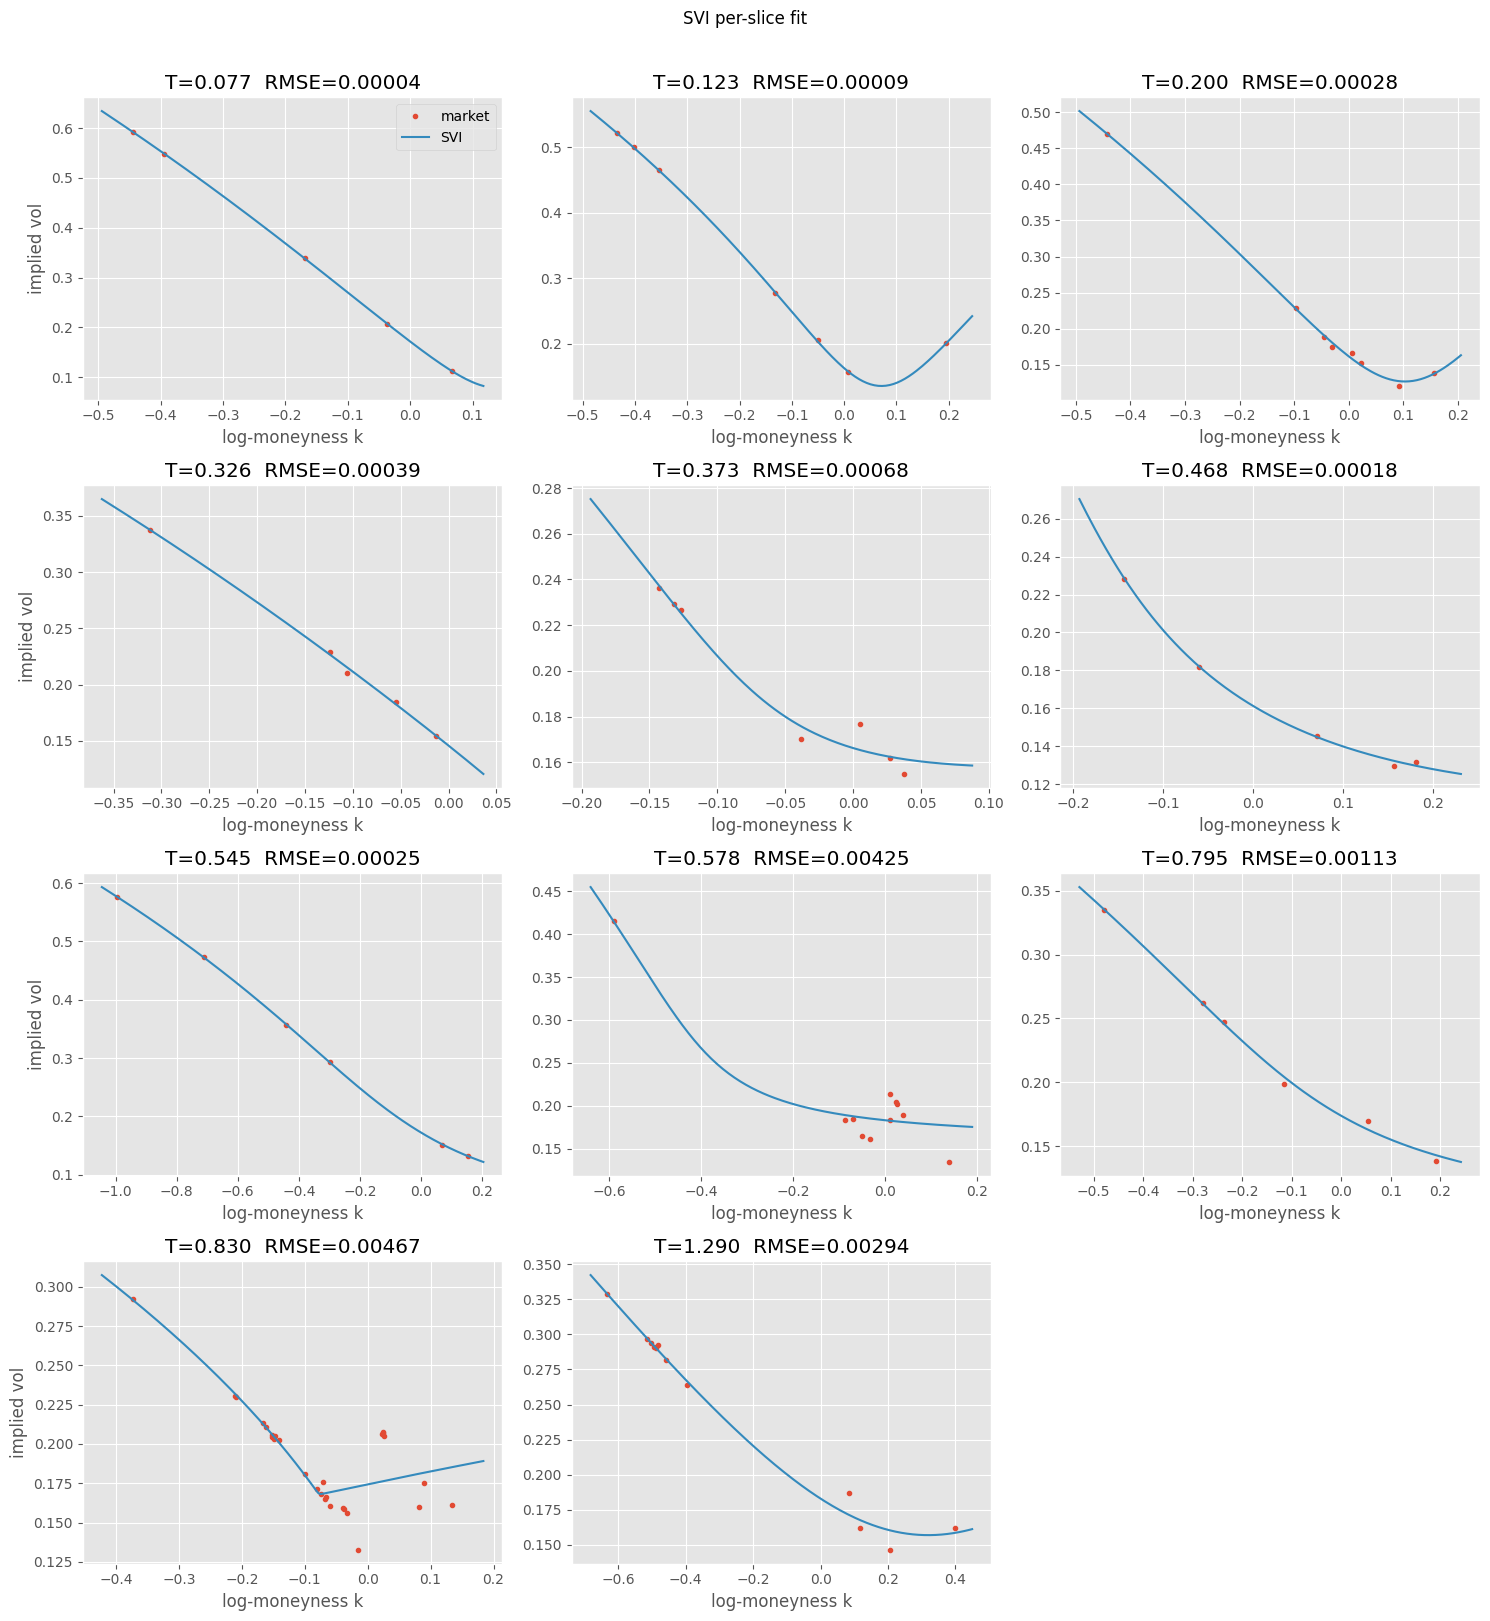

In [5]:
n_slices = len(slices)
fig, axes = plt.subplots(
    (n_slices + 2) // 3, 3,
    figsize=(15, 4 * ((n_slices + 2) // 3)),
    squeeze=False
)

for i, (s, row) in enumerate(zip(slices, svi_results)):
    ax = axes[i // 3][i % 3]
    k_fine = np.linspace(s['k'].min() - 0.05, s['k'].max() + 0.05, 200)

    # reconstruct SVI params
    p = cppfm.SviParams(row['a'], row['b'], row['rho'], row['m'], row['sigma'])
    iv_fit = [p.implied_vol(ki, s['T']) for ki in k_fine]

    ax.plot(s['k'], s['ivs'], 'o', ms=3, label='market')
    ax.plot(k_fine, iv_fit, '-', lw=1.5, label='SVI')
    ax.set_title(f"T={s['T']:.3f}  RMSE={row['rmse']:.5f}")
    ax.set_xlabel('log-moneyness k')
    if i % 3 == 0:
        ax.set_ylabel('implied vol')

# hide unused subplots
for j in range(i + 1, axes.size):
    axes.flat[j].set_visible(False)

axes[0][0].legend()
fig.suptitle('SVI per-slice fit', y=1.01)
plt.tight_layout()
plt.show()

## Global SSVI

3 global parameters $(\rho, \eta, \gamma)$ + per-maturity $\theta_T$. Cross-slice consistency enforced.

In [6]:
strikes_per_mat = [s['strikes'].tolist() for s in slices]
vols_per_mat = [s['ivs'].tolist() for s in slices]
forwards = [float(s['F']) for s in slices]
maturities = [float(s['T']) for s in slices]

ssvi_result = cppfm.calibrate_ssvi(strikes_per_mat, vols_per_mat, forwards, maturities)

p = ssvi_result.params
print(f"rho   = {p.rho:.6f}")
print(f"eta   = {p.eta:.6f}")
print(f"gamma = {p.gamma:.6f}")
print(f"RMSE  = {ssvi_result.rmse:.6f}")
print(f"converged     = {ssvi_result.converged}")
print(f"arbitrage_free = {ssvi_result.arbitrage_free}")

# per-maturity thetas
theta_df = pd.DataFrame({
    'T': maturities,
    'theta': ssvi_result.thetas,
    'ATM_vol': [np.sqrt(th / T) for th, T in zip(ssvi_result.thetas, maturities)]
})
theta_df

rho   = -0.483317
eta   = 0.954477
gamma = 0.587789
RMSE  = 0.012686
converged     = True
arbitrage_free = True


,T,theta,ATM_vol
0,0.076712,0.002330,0.174277
1,0.123288,0.003268,0.162819
2,0.200000,0.005636,0.167867
3,0.326027,0.007749,0.154172
4,0.372603,0.011509,0.175749
5,0.468493,0.012890,0.165875
6,0.545205,0.016142,0.172066
7,0.578082,0.023175,0.200223
8,0.794521,0.025462,0.179018
9,0.830137,0.025462,0.175135


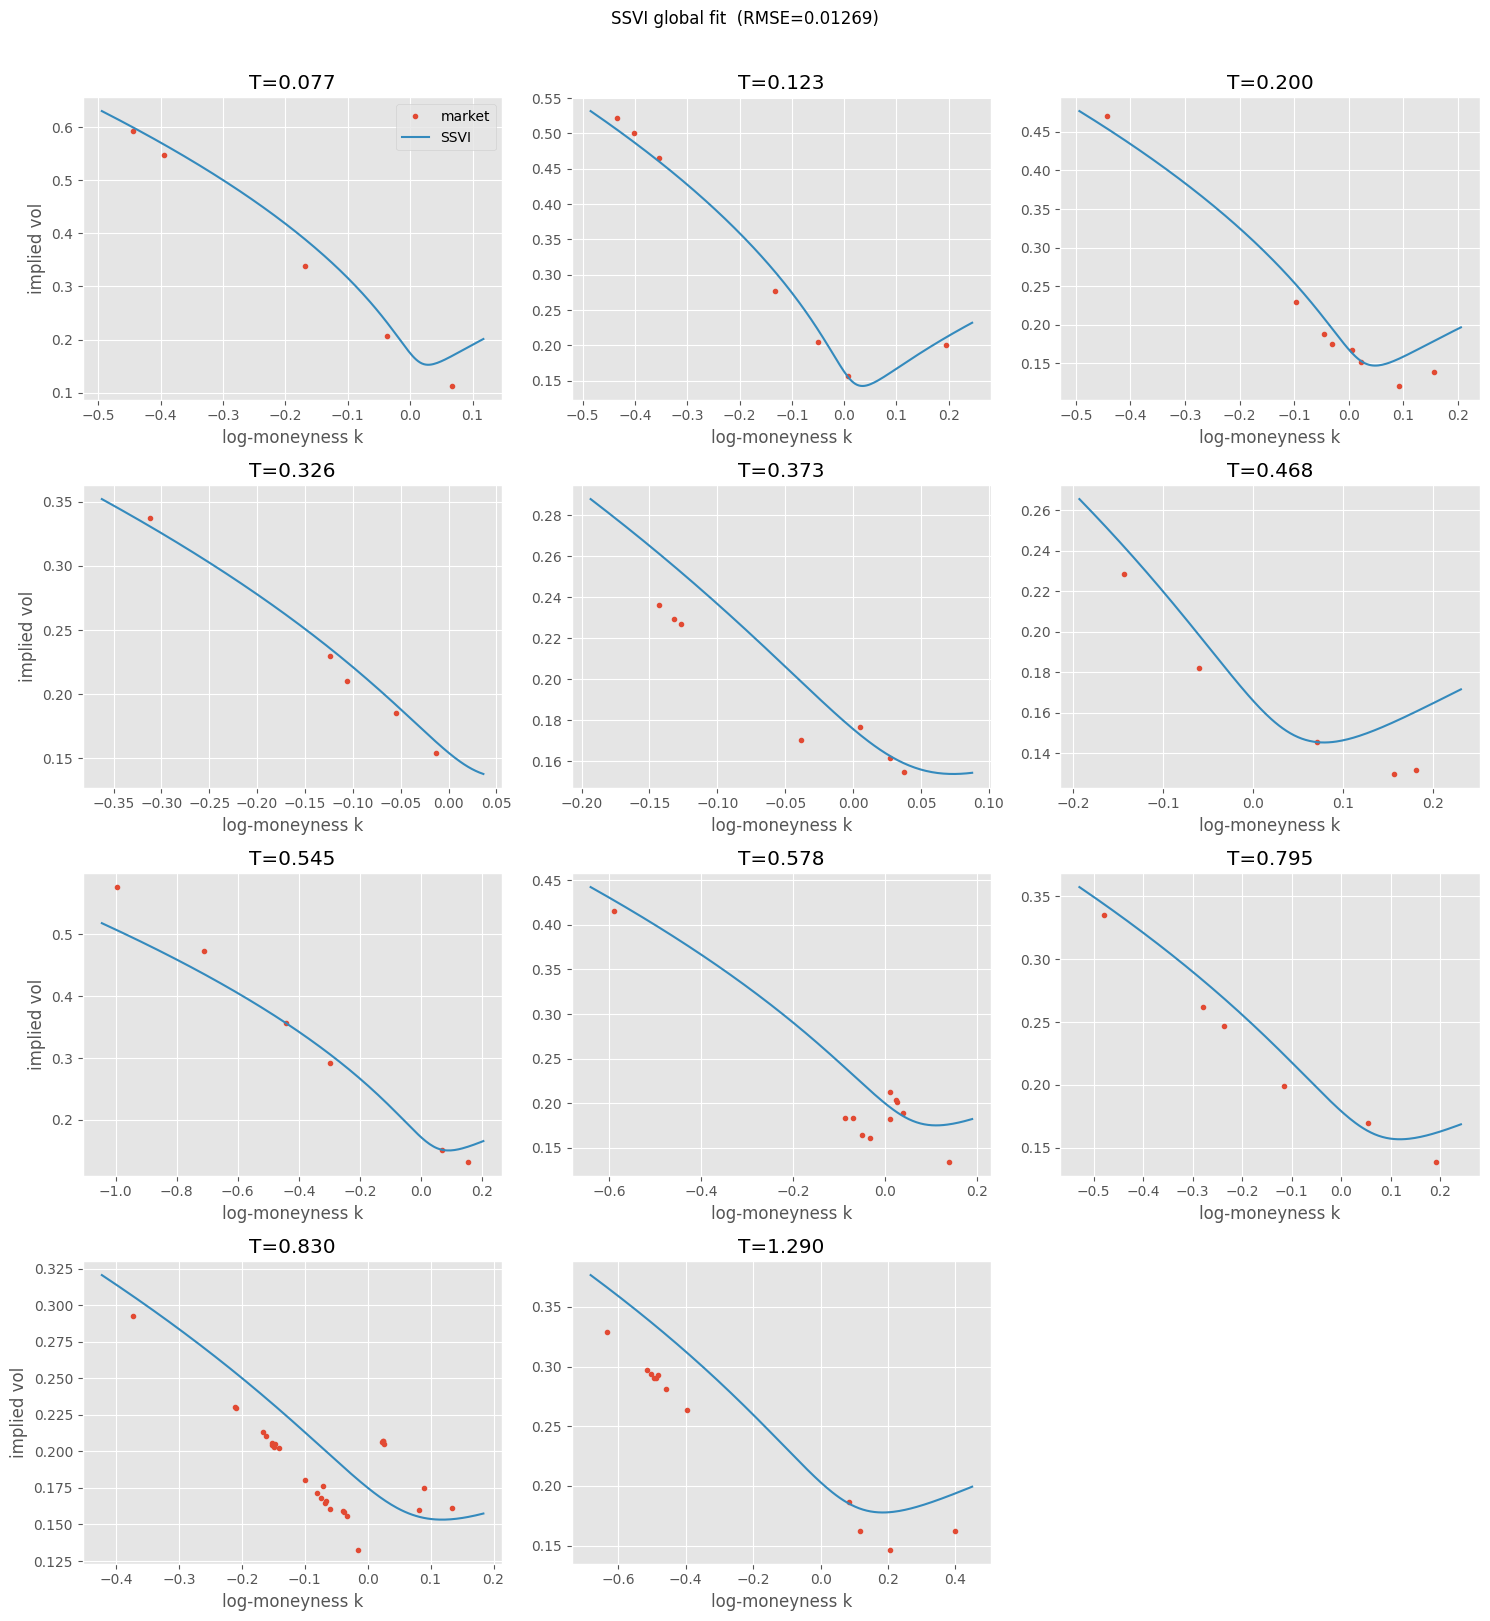

In [7]:
fig, axes = plt.subplots(
    (n_slices + 2) // 3, 3,
    figsize=(15, 4 * ((n_slices + 2) // 3)),
    squeeze=False
)

params = ssvi_result.params
for i, s in enumerate(slices):
    ax = axes[i // 3][i % 3]
    k_fine = np.linspace(s['k'].min() - 0.05, s['k'].max() + 0.05, 200)

    # set theta for this maturity
    params.theta = ssvi_result.thetas[i]
    iv_fit = [params.implied_vol(ki, s['T']) for ki in k_fine]

    ax.plot(s['k'], s['ivs'], 'o', ms=3, label='market')
    ax.plot(k_fine, iv_fit, '-', lw=1.5, label='SSVI')
    ax.set_title(f"T={s['T']:.3f}")
    ax.set_xlabel('log-moneyness k')
    if i % 3 == 0:
        ax.set_ylabel('implied vol')

for j in range(i + 1, axes.size):
    axes.flat[j].set_visible(False)

axes[0][0].legend()
fig.suptitle(f'SSVI global fit  (RMSE={ssvi_result.rmse:.5f})', y=1.01)
plt.tight_layout()
plt.show()

## Arbitrage checks

Two conditions for no static arbitrage: butterfly (density $g(k) \geq 0$) and calendar spread (total variance non-decreasing in $T$).

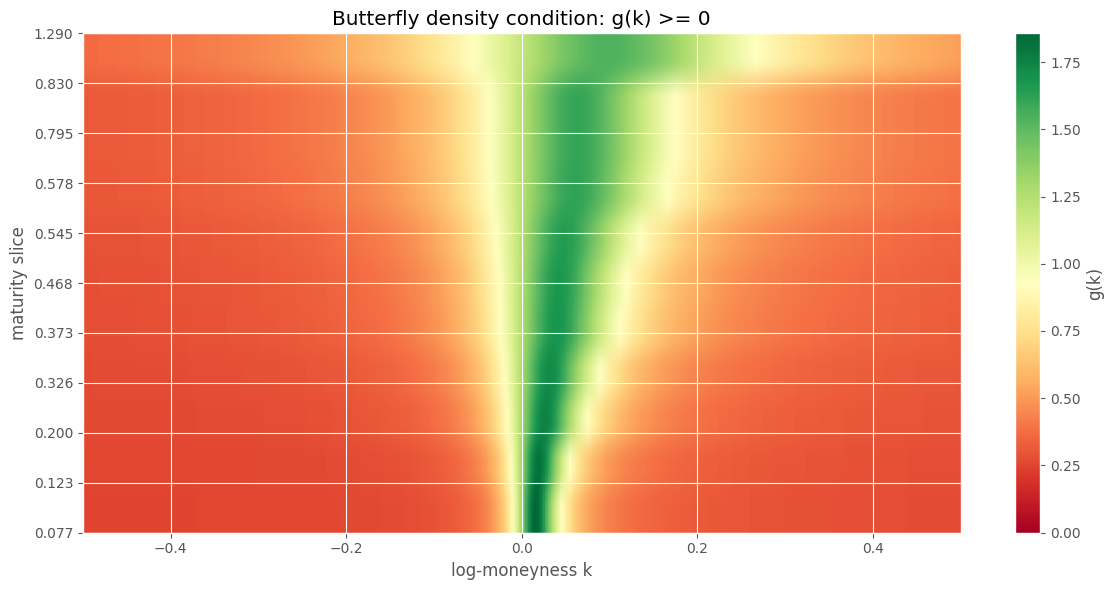

min g(k) across surface: 0.25222256


In [8]:
params = ssvi_result.params
k_grid = np.linspace(-0.5, 0.5, 300)

g_values = np.zeros((len(slices), len(k_grid)))
for i, s in enumerate(slices):
    params.theta = ssvi_result.thetas[i]
    for j, k in enumerate(k_grid):
        g_values[i, j] = params.g_function(k)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(
    g_values, aspect='auto', origin='lower',
    extent=[k_grid[0], k_grid[-1], 0, len(slices) - 1],
    cmap='RdYlGn', vmin=0
)
ax.set_xlabel('log-moneyness k')
ax.set_ylabel('maturity slice')
ax.set_yticks(range(len(slices)))
ax.set_yticklabels([f"{s['T']:.3f}" for s in slices])
plt.colorbar(im, label='g(k)')
ax.set_title('Butterfly density condition: g(k) >= 0')
plt.tight_layout()
plt.show()

print(f"min g(k) across surface: {g_values.min():.8f}")

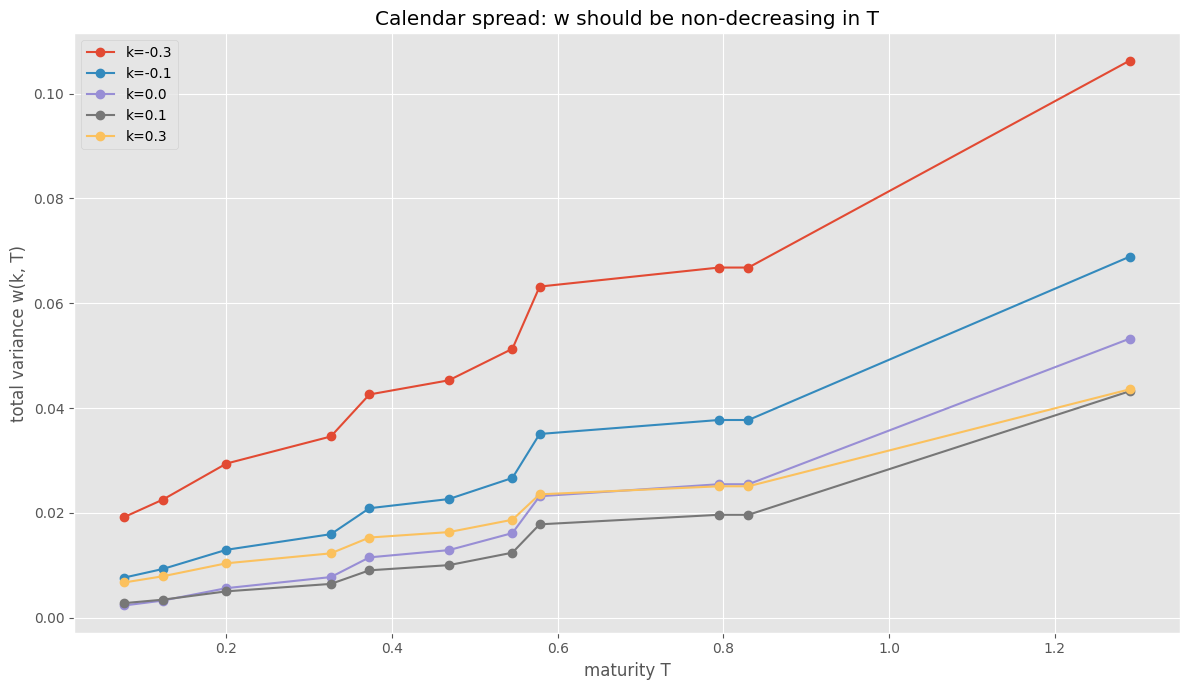

In [9]:
# total variance at fixed moneyness levels across maturities
k_test = [-0.3, -0.1, 0.0, 0.1, 0.3]

fig, ax = plt.subplots()
for k_val in k_test:
    w_vals = []
    for i in range(len(slices)):
        params.theta = ssvi_result.thetas[i]
        w_vals.append(params.total_variance(k_val))
    ax.plot(maturities, w_vals, 'o-', label=f'k={k_val}')

ax.set_xlabel('maturity T')
ax.set_ylabel('total variance w(k, T)')
ax.set_title('Calendar spread: w should be non-decreasing in T')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
constraint_rows = []
for i, s in enumerate(slices):
    params.theta = ssvi_result.thetas[i]
    constraint_rows.append({
        'T': s['T'],
        'theta': ssvi_result.thetas[i],
        'butterfly_ok': params.satisfies_butterfly_constraint(ssvi_result.thetas[i]),
        'all_constraints_ok': params.satisfies_constraints()
    })

constraint_df = pd.DataFrame(constraint_rows)
constraint_df

,T,theta,butterfly_ok,all_constraints_ok
0,0.076712,0.002330,True,True
1,0.123288,0.003268,True,True
2,0.200000,0.005636,True,True
3,0.326027,0.007749,True,True
4,0.372603,0.011509,True,True
5,0.468493,0.012890,True,True
6,0.545205,0.016142,True,True
7,0.578082,0.023175,True,True
8,0.794521,0.025462,True,True
9,0.830137,0.025462,True,True


## Implied vol and local vol surfaces

In [11]:
import plotly.graph_objects as go

surface = ssvi_result.build_analytical_surface(forwards)

# implied vol surface
K_plot = np.linspace(S0 * 0.85, S0 * 1.15, 100)
T_plot = np.linspace(maturities[0], maturities[-1], 50)
K_mesh, T_mesh = np.meshgrid(K_plot, T_plot)

IV_mesh = np.zeros_like(K_mesh)
for i in range(K_mesh.shape[0]):
    for j in range(K_mesh.shape[1]):
        IV_mesh[i, j] = surface.implied_volatility(K_mesh[i, j], T_mesh[i, j])

fig = go.Figure(data=[go.Surface(x=K_mesh, y=T_mesh, z=IV_mesh, colorscale='Viridis')])
fig.update_layout(
    title='SSVI Implied Volatility Surface',
    scene=dict(xaxis_title='Strike K', yaxis_title='Maturity T', zaxis_title='Implied Vol'),
    width=900, height=700
)
fig.show()

In [12]:
# analytical Dupire local vol — no grid, no finite differences
S_plot = np.linspace(S0 * 0.8, S0 * 1.2, 100)
T_lv = np.linspace(maturities[0] + 0.01, maturities[-1] - 0.01, 50)
S_mesh, T_lv_mesh = np.meshgrid(S_plot, T_lv)

LV_mesh = np.zeros_like(S_mesh)
for i in range(S_mesh.shape[0]):
    for j in range(S_mesh.shape[1]):
        LV_mesh[i, j] = surface.local_volatility(S_mesh[i, j], T_lv_mesh[i, j])

fig = go.Figure(data=[go.Surface(x=S_mesh, y=T_lv_mesh, z=LV_mesh, colorscale='Inferno')])
fig.update_layout(
    title='Dupire Local Volatility Surface (analytical)',
    scene=dict(xaxis_title='Spot S', yaxis_title='Time t', zaxis_title='Local Vol'),
    width=900, height=700
)
fig.show()